# Lorenz Part 1 — Multi-trajectory GLS

This notebook compares high- and low-fidelity ensembles for the Lorenz system using the multi-trajectory (Part 1) workflow.

Steps:
1. configure and run the Monte Carlo experiment,
2. preview representative trajectories,
3. visualise coefficient/support errors.


## Governing equations

The classic Lorenz-63 dynamics are

$$
\begin{align*}
\dot{x} &= \sigma (y - x), \\
\dot{y} &= x (\rho - z) - y, \\
\dot{z} &= x y - \beta z.
\end{align*}
$$

We use $(\sigma,\rho,\beta) = (10, 28, 8/3)$ with $n_{HF}$ high-fidelity and $n_{LF}$ low-fidelity trajectories.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (register 3D projection)
import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.lorenz import (
    LorenzMultiTrajectoryGLSConfig,
    generate_lorenz_dataset,
    run_lorenz_multi_trajectory_gls_experiment,
)
from mfsindy.cases.lorenz_plots import COLORS_MODELS
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white")

RESULTS_DIR = Path("examples") / "lorenz" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["HF", "LF", "MF", "MF_w"]
PLOT_ORDER = ["MF_w", "MF", "HF", "LF"]




In [2]:
cfg = LorenzMultiTrajectoryGLSConfig(
    n_runs=5,
    results_dir=str(RESULTS_DIR),
    results_filename="lorenz_part1_errors.csv",
)

print(
    f"Running Part 1 Lorenz experiment with n_LF={cfg.n_lf}, n_HF={cfg.n_hf}, "
    f"noise_rel(LF)={cfg.noise_lf_rel}, noise_rel(HF)={cfg.noise_hf_rel}."
)

(
    _df_errors,
    _mae_errors,
    _l0_errors,
    state_std,
    noise_hf_abs,
    noise_lf_abs,
) = run_lorenz_multi_trajectory_gls_experiment(cfg)

errors_path = Path(cfg.results_dir) / cfg.results_filename
df_errors = pd.read_csv(errors_path)

def metric_values(metric: str) -> dict[str, np.ndarray]:
    return {
        m: df_errors[(df_errors["model"] == m) & (df_errors["metric"] == metric)]["value"].to_numpy()
        for m in MODELS
    }

def summarise(errors: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for model, values in errors.items():
        arr = np.asarray(values, dtype=float)
        if arr.size == 0:
            continue
        rows.append(
            {
                "model": model,
                "median": float(np.median(arr)),
                "q25": float(np.percentile(arr, 25.0)),
                "q75": float(np.percentile(arr, 75.0)),
            }
        )
    return pd.DataFrame(rows).set_index("model")

mae_errors = metric_values("MAE")
l0_errors = metric_values("L0")
mae_summary = summarise(mae_errors)
l0_summary = summarise(l0_errors)

print("Reference state std:", state_std)
print("HF abs noise:", noise_hf_abs)
print("LF abs noise:", noise_lf_abs)


Running Part 1 Lorenz experiment with n_LF=100, n_HF=10, noise_rel(LF)=0.25, noise_rel(HF)=0.01.


Monte Carlo Lorenz MF: 100%|██████████| 5/5 [01:23<00:00, 16.78s/it]

Reference state std: 13.482370246888038
HF abs noise: 0.1348237024688804
LF abs noise: 3.3705925617220096


### Trajectory snapshot
Preview noisy LF/HF trajectories vs. a long clean reference.


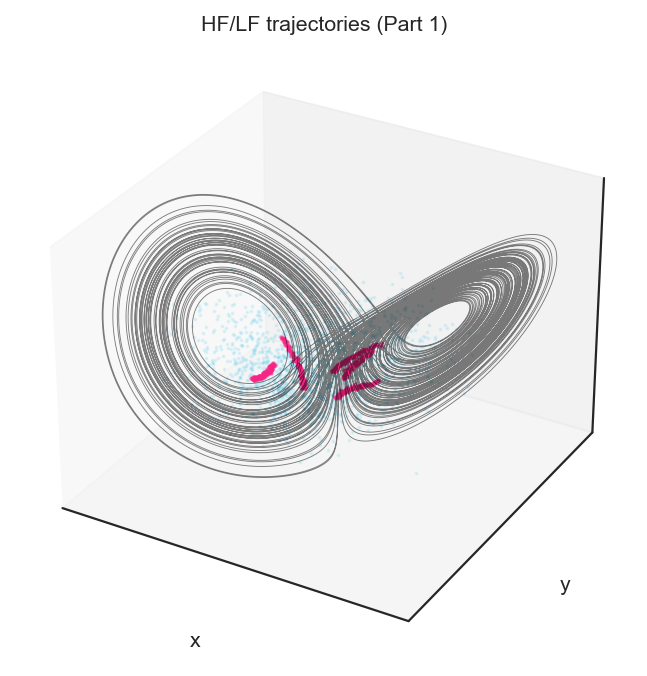

In [3]:
X_hf_batch, t_train, _ = generate_lorenz_dataset(
    n_traj=cfg.n_hf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=noise_hf_abs,
    seed=cfg.seed_base + 5,
)
X_lf_batch, _, _ = generate_lorenz_dataset(
    n_traj=cfg.n_lf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=noise_lf_abs,
    seed=cfg.seed_base + 125,
)
X_clean, _, _ = generate_lorenz_dataset(
    n_traj=1,
    T=cfg.T_true,
    dt=cfg.dt,
    noise_level=0.0,
    seed=cfg.seed_base,
)

fig = plt.figure(figsize=(5, 5), dpi=160)
ax = fig.add_subplot(111, projection="3d")
ax.set_title("HF/LF trajectories (Part 1)")

for traj in X_lf_batch[: min(15, len(X_lf_batch))]:
    ax.plot(
        traj[:, 0],
        traj[:, 1],
        traj[:, 2],
        ".",
        alpha=0.15,
        color=COLORS_MODELS["LF"],
        markersize=1.4,
    )
for traj in X_hf_batch[: min(5, len(X_hf_batch))]:
    ax.plot(
        traj[:, 0],
        traj[:, 1],
        traj[:, 2],
        ".",
        alpha=0.6,
        color=COLORS_MODELS["HF"],
        markersize=1.8,
    )
ax.plot(
    X_clean[0][:, 0],
    X_clean[0][:, 1],
    X_clean[0][:, 2],
    color="black",
    linewidth=0.4,
    alpha=0.5,
)
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.grid(False)
plt.show()



### Error summaries
Bubble histograms summarise the MAE and $L_0$ distributions across methods.


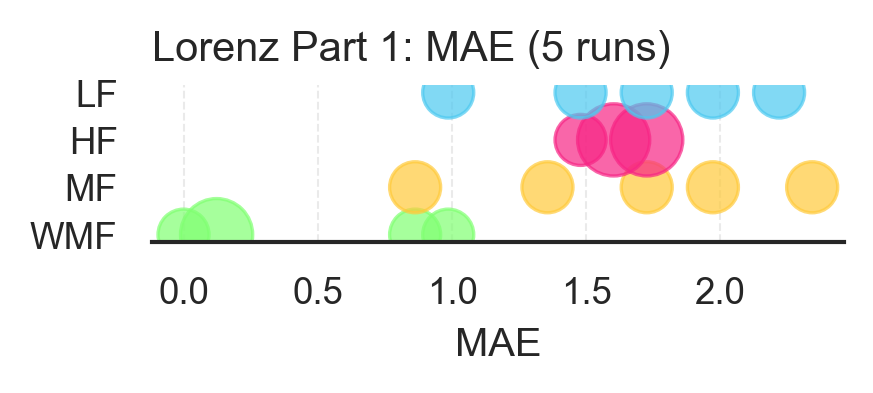

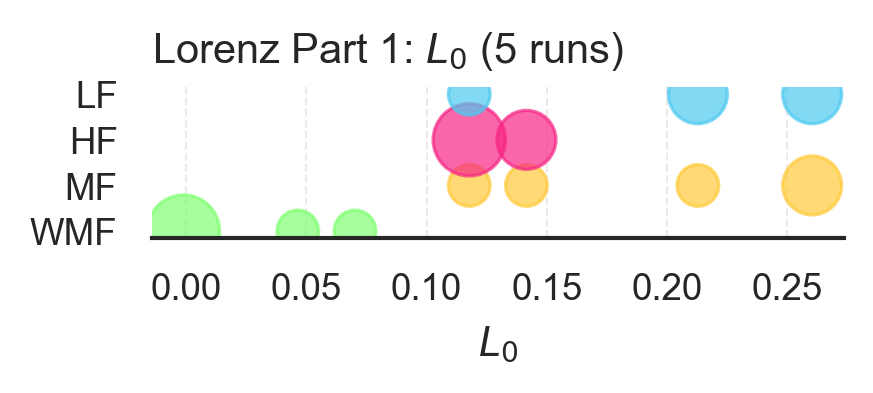

In [4]:
method_colors = {m: COLORS_MODELS.get(m, "tab:gray") for m in MODELS}
labels = ["WMF", "MF", "HF", "LF"]

bubble_hist(
    errors_dict=mae_errors,
    title=f"Lorenz Part 1: MAE ({cfg.n_runs} runs)",
    xlabel="MAE",
    n_bins=20,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

bubble_hist(
    errors_dict=l0_errors,
    title=f"Lorenz Part 1: $L_0$ ({cfg.n_runs} runs)",
    xlabel=r"$L_0$",
    n_bins=12,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

